In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics
import matplotlib.pyplot as plt

In [7]:
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)
df.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [8]:
X=df[['gre','gpa','rank']]
y=df['admit']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=1)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

acc = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.758


## confution metrics

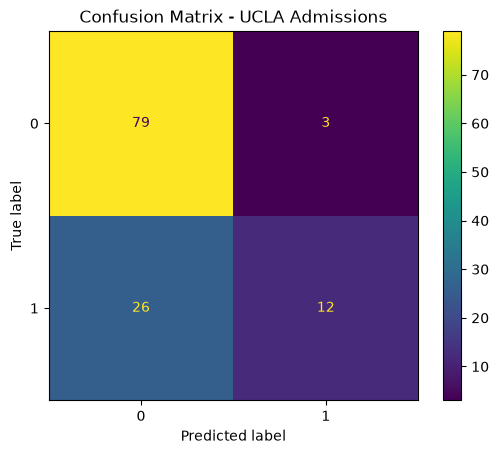

In [17]:
cm= metrics.confusion_matrix(y_test,y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format='d') # d means decimal numbers
plt.title("Confusion Matrix - UCLA Admissions")
plt.show()

**Precision**: The accuracy of predictions about admitted applicants compared to actual admissions.
**Recall**: The share of actual admissions correctly predicted by your model

In [21]:
prec = metrics.precision_score(y_test, y_pred, zero_division=0)
# zero_division : "If you have to divide by zero, skip the warning and just set the precision score to 0."

rec = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"Precision: {prec: .3f} \nRecall: {rec:.3f} \nF1 score: {f1:.3f}")


Precision:  0.800 
Recall: 0.316 
F1 score: 0.453


> close to 0.0 bad. close to 1.0 godd

- High Precision, Low Recall: The model is very careful. When it predicts a positive result, it is almost always right. However, it misses a large number of actual positive cases because it is too timid.

- Low Precision, High Recall: The model is aggressive. It successfully captures almost all positive cases, but it casts such a wide net that it also flags a massive number of negative cases by mistake.

- High F1-Score: This is your target. It proves that the model has successfully minimized both false alarms (False Positives) and missed targets (False Negatives).

### ROC Curve

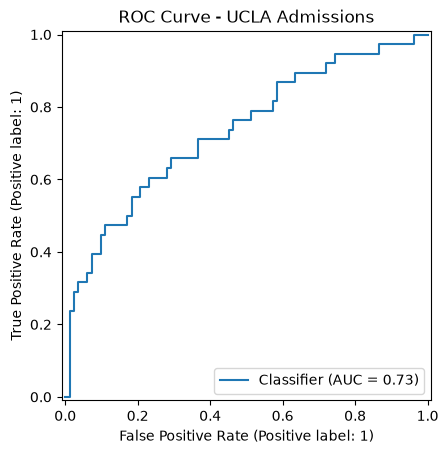

In [23]:
metrics.RocCurveDisplay.from_predictions(y_test,y_prob)
plt.title("ROC Curve - UCLA Admissions")
plt.show()

### ROC AUC (Area under the Curve)

In [24]:
auc = metrics.roc_auc_score(y_test,y_prob)
print(f"AUC: {auc:.3f}")

AUC: 0.735
